

**import all the nedded library**




In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
df = pd.read_csv('/content/drive/MyDrive/ipl-project/IPL Matches 2008-2020.csv')
print("Loaded! ✅")

Loaded! ✅


In [26]:
df.head()

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,NaN,SJ Davis,DJ Harper
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,NaN,BF Bowden,K Hariharan


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               816 non-null    int64  
 1   city             803 non-null    object 
 2   date             816 non-null    object 
 3   player_of_match  812 non-null    object 
 4   venue            816 non-null    object 
 5   neutral_venue    816 non-null    int64  
 6   team1            816 non-null    object 
 7   team2            816 non-null    object 
 8   toss_winner      816 non-null    object 
 9   toss_decision    816 non-null    object 
 10  winner           812 non-null    object 
 11  result           812 non-null    object 
 12  result_margin    799 non-null    float64
 13  eliminator       812 non-null    object 
 14  method           19 non-null     object 
 15  umpire1          816 non-null    object 
 16  umpire2          816 non-null    object 
dtypes: float64(1), i

In [28]:
df.isnull().sum()

,0
id,0
city,13
date,0
player_of_match,4
venue,0
neutral_venue,0
team1,0
team2,0
toss_winner,0
toss_decision,0


**cleanign the null values**

In [29]:
df['winner'].fillna('No Result', inplace=True)
df['player_of_match'].fillna('Unknown', inplace=True)
df['result'].fillna('No Result', inplace=True)
df['result_margin'].fillna(0, inplace=True)
df['eliminator'].fillna('N', inplace=True)
df['method'].fillna('Normal', inplace=True)

print("Cleaning Done ✅")
df.isnull().sum()

Cleaning Done ✅


/tmp/ipykernel_15518/2648249273.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['winner'].fillna('No Result', inplace=True)
/tmp/ipykernel_15518/2648249273.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

,0
id,0
city,13
date,0
player_of_match,0
venue,0
neutral_venue,0
team1,0
team2,0
toss_winner,0
toss_decision,0


In [30]:
top_teams= df["winner"].value_counts().head(10)
top_teams

,count
winner,
Mumbai Indians,120
Chennai Super Kings,106
Kolkata Knight Riders,99
Royal Challengers Bangalore,91
Kings XI Punjab,88
Rajasthan Royals,81
Delhi Daredevils,67
Sunrisers Hyderabad,66
Deccan Chargers,29


/tmp/ipykernel_15518/1781199246.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_teams.values,y=top_teams.index,palette="viridis")


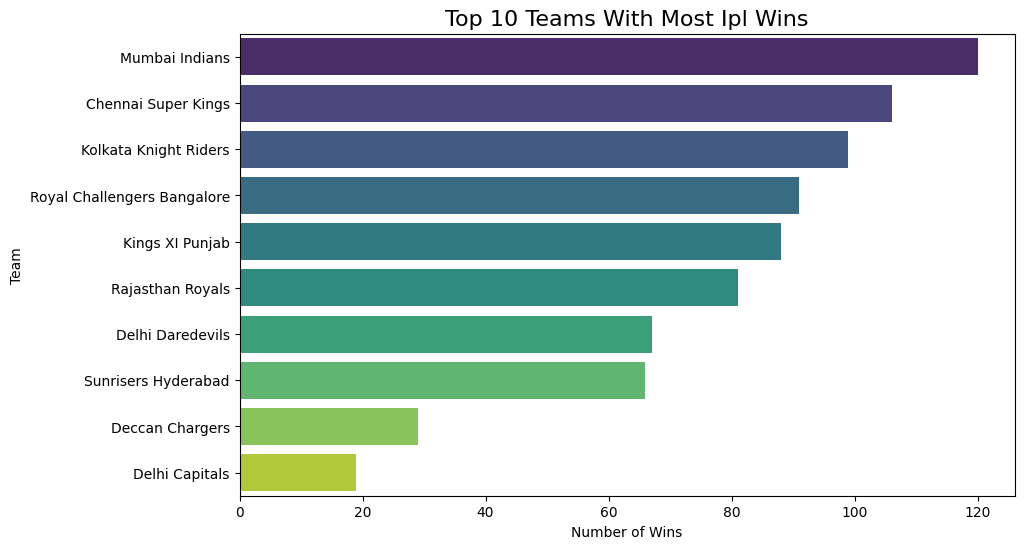

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_teams.values,y=top_teams.index,palette="viridis")
plt.title("Top 10 Teams With Most Ipl Wins",fontsize=16)
plt.xlabel("Number of Wins")
plt.ylabel("Team")
plt.tight_layout
plt.show()

In [32]:
#toss winning effect on match result
df["toss_match_winner"]=df["toss_winner"]==df["winner"]
effect=df["toss_match_winner"].value_counts()
effect

,count
toss_match_winner,
True,418
False,398


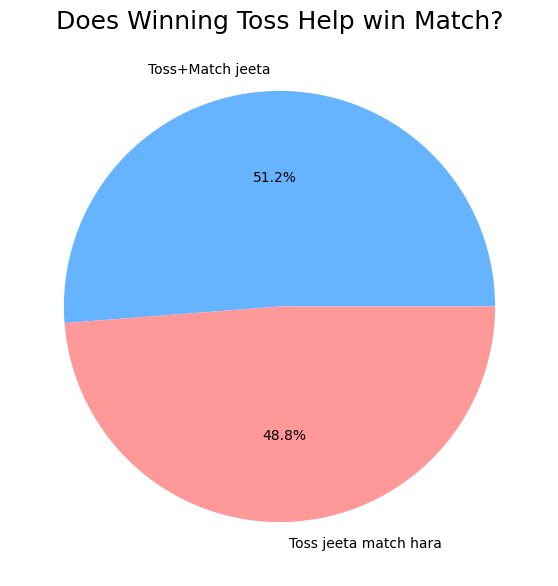

In [33]:
labels=["Toss+Match jeeta","Toss jeeta match hara"  ]
plt.figure(figsize=(7,7))
plt.pie(effect.values,labels=labels,autopct='%1.1f%%',colors=['#66b3ff','#ff9999'])
plt.title("Does Winning Toss Help win Match?",fontsize=18)
plt.show()

In [34]:
df

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,toss_match_winner
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,Normal,Asad Rauf,RE Koertzen,False
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,Normal,MR Benson,SL Shastri,True
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,Normal,Aleem Dar,GA Pratapkumar,False
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,Normal,SJ Davis,DJ Harper,False
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,Normal,BF Bowden,K Hariharan,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,1216547,Dubai,2020-09-28,AB de Villiers,Dubai International Cricket Stadium,0,Royal Challengers Bangalore,Mumbai Indians,Mumbai Indians,field,Royal Challengers Bangalore,tie,0.0,Y,Normal,Nitin Menon,PR Reiffel,False
812,1237177,Dubai,2020-11-05,JJ Bumrah,Dubai International Cricket Stadium,0,Mumbai Indians,Delhi Capitals,Delhi Capitals,field,Mumbai Indians,runs,57.0,N,Normal,CB Gaffaney,Nitin Menon,False
813,1237178,Abu Dhabi,2020-11-06,KS Williamson,Sheikh Zayed Stadium,0,Royal Challengers Bangalore,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Sunrisers Hyderabad,wickets,6.0,N,Normal,PR Reiffel,S Ravi,True
814,1237180,Abu Dhabi,2020-11-08,MP Stoinis,Sheikh Zayed Stadium,0,Delhi Capitals,Sunrisers Hyderabad,Delhi Capitals,bat,Delhi Capitals,runs,17.0,N,Normal,PR Reiffel,S Ravi,True


/tmp/ipykernel_15518/1972105482.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_players.values,y=top_players.index,palette="magma") #paletter means color


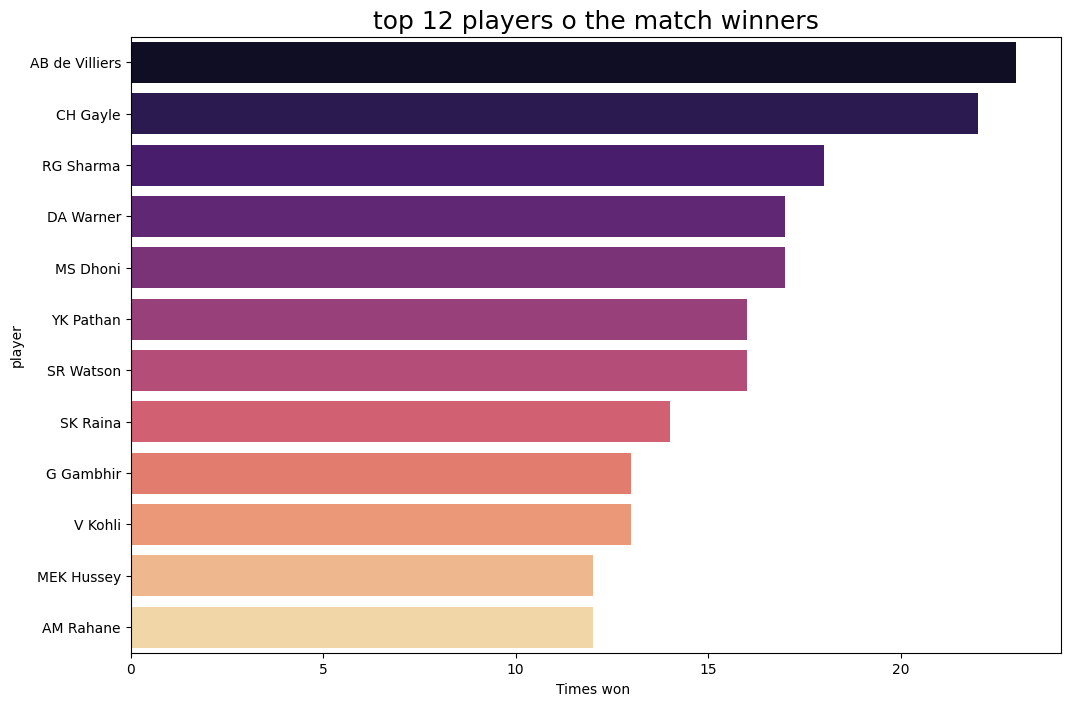

In [38]:
#now i want to plot top players
top_players=df["player_of_match"].value_counts().head(12)
plt.figure(figsize=(12,8)) #graph size
sns.barplot(x=top_players.values,y=top_players.index,palette="magma") #paletter means color
plt.title("top 12 players o the match winners",fontsize=18)
plt.xlabel("Times won ")
plt.ylabel("player")
plt.show()


In [45]:
print(df['date'].head(10))
print(df['date'].dtype)

0    2008-04-18
1    2008-04-19
2    2008-04-19
3    2008-04-20
4    2008-04-20
5    2008-04-21
6    2008-04-22
7    2008-04-23
8    2008-04-24
9    2008-04-25
Name: date, dtype: object
object


In [46]:
df['year'] = df['date'].str[:4].astype(int)
season_matches = df['year'].value_counts().sort_index()

print(season_matches)

year
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
2020    60
Name: count, dtype: int64


In [49]:
print(type(season_matches.values))
print(season_matches.values)

<class 'numpy.ndarray'>
[58 57 60 73 74 76 60 59 60 59 60 60 60]


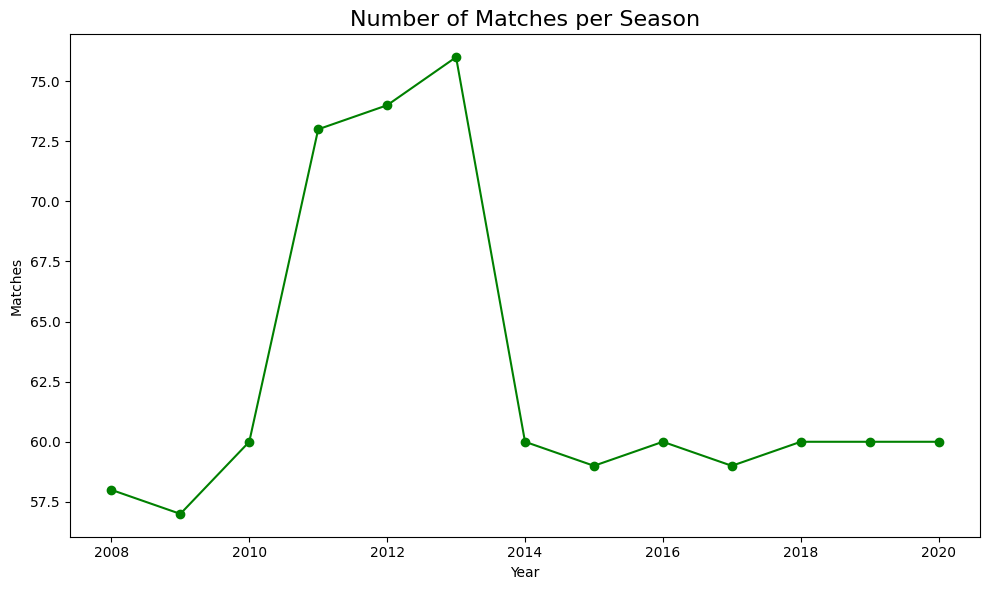

In [50]:
#number of matches per season
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(season_matches.index, season_matches.values, marker='o', color='green')
ax.set_title('Number of Matches per Season', fontsize=16)
ax.set_xlabel('Year')
ax.set_ylabel('Matches')
plt.tight_layout()
plt.show()

In [40]:
print(df.columns.tolist())#list of columns

['id', 'city', 'date', 'player_of_match', 'venue', 'neutral_venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'eliminator', 'method', 'umpire1', 'umpire2', 'toss_match_winner']


# ## 📌 Key Findings

1. **Mumbai Indians** won the most IPL matches overall
2. Winning toss has very little effect — only **51.2%** win rate
3. **AB de Villiers** won Player of the Match most times (23+)
4. IPL had most matches in **2013** season
5. CH Gayle and RG Sharma are top performers overall

## 🔧 Tools Used
- Python, Pandas, NumPy, Matplotlib, Seaborn

## 📁 Dataset
- IPL Matches 2008-2020